In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')



In [15]:
df = pd.read_csv(r"C:\Users\reddy\Downloads\archive (3)\salesdaily.csv")

print(f"Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Dataset loaded!
Shape: (2106, 13)

Columns: ['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06', 'Year', 'Month', 'Hour', 'Weekday Name']

First 5 rows:


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [16]:
# Convert date column
df['datum'] = pd.to_datetime(df['datum'])

# Add total daily sales column
drug_cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
df['total_sales'] = df[drug_cols].sum(axis=1)

# Add day of week number
df['day_num'] = df['datum'].dt.dayofweek

print(" Data cleaned!")
print(f"\nDate range: {df['datum'].min()} to {df['datum'].max()}")
print(f"\nTotal Sales Stats:")
print(df['total_sales'].describe().apply(lambda x: f"{x:.2f}"))
print(f"\nMissing values: {df.isnull().sum().sum()}")
df.head()

 Data cleaned!

Date range: 2014-01-02 00:00:00 to 2019-10-08 00:00:00

Total Sales Stats:
count    2106.00
mean       60.59
std        21.56
min         0.00
25%        46.45
50%        58.47
75%        72.81
max       198.95
Name: total_sales, dtype: object

Missing values: 0


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name,total_sales,day_num
0,2014-01-02,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday,48.47,3
1,2014-01-03,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday,107.00,4
2,2014-01-04,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday,91.35,5
3,2014-01-05,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday,66.10,6
4,2014-01-06,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday,58.20,0


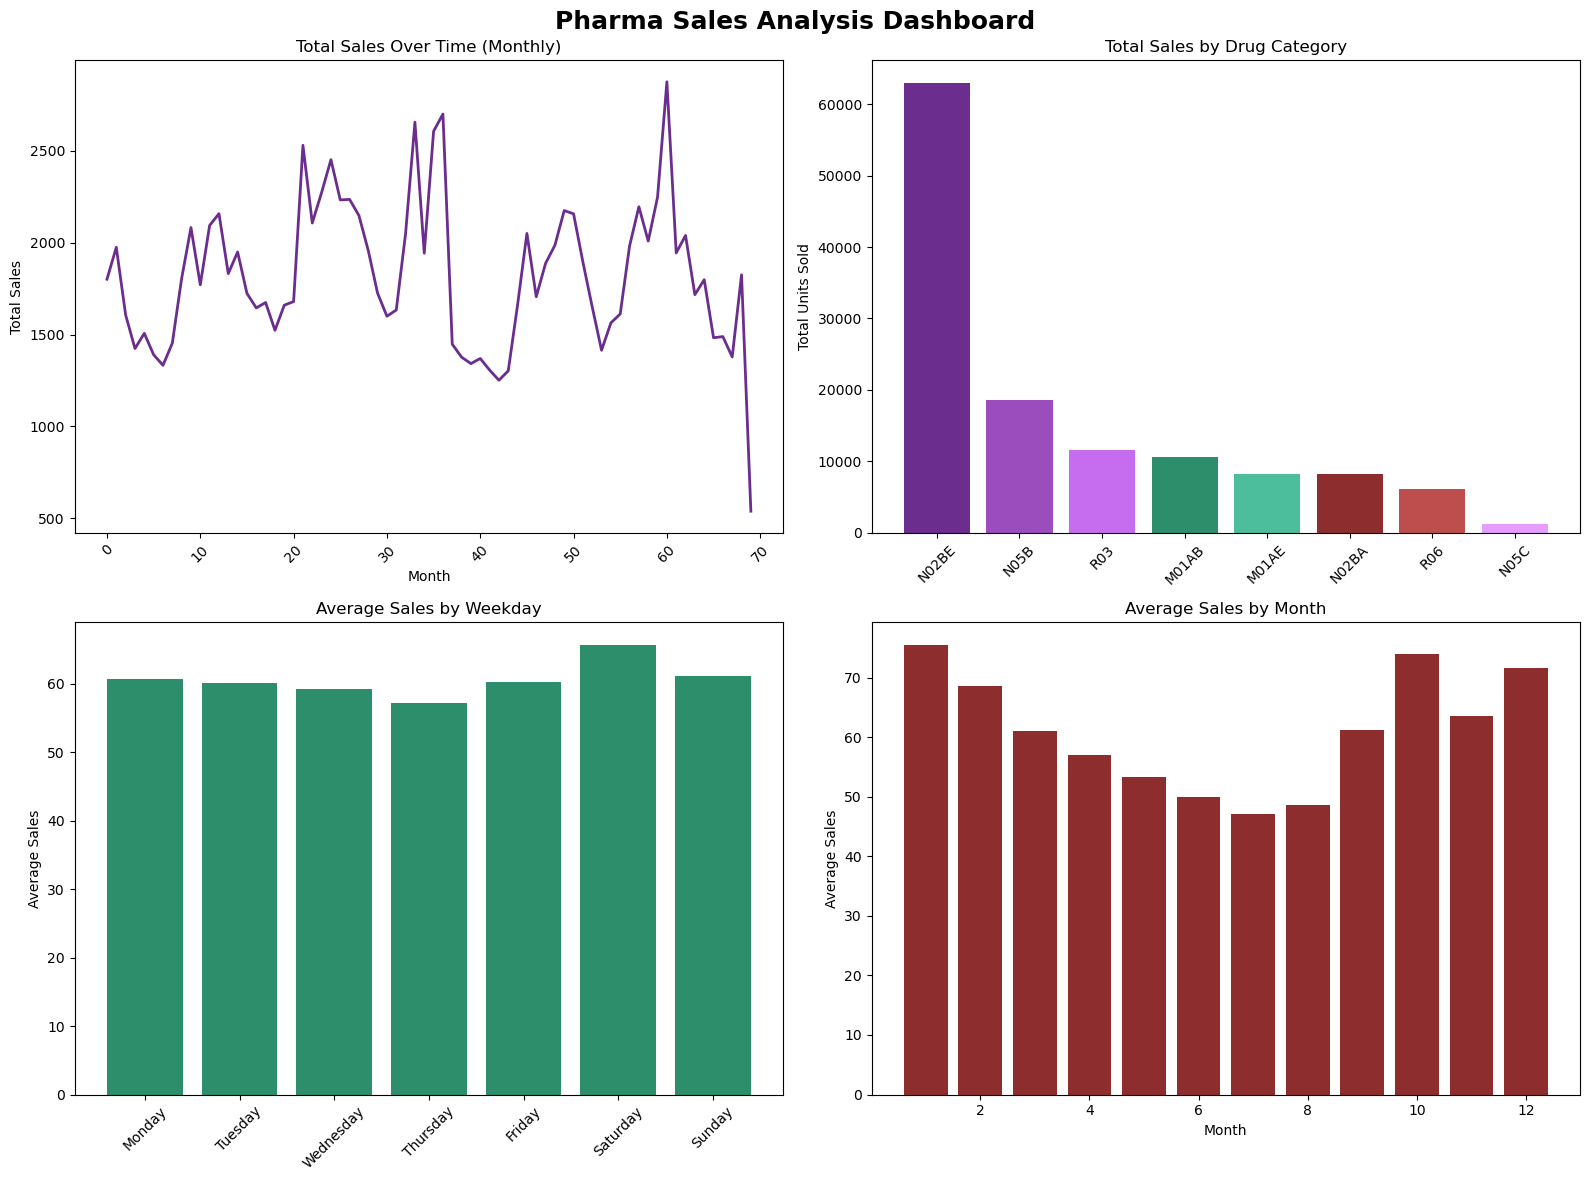

 Dashboard saved!


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Pharma Sales Analysis Dashboard', fontsize=18, fontweight='bold')

# Plot 1 - Total sales over time
monthly = df.groupby(['Year', 'Month'])['total_sales'].sum().reset_index()
monthly['period'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)
axes[0,0].plot(range(len(monthly)), monthly['total_sales'], color='#6B2D8E', linewidth=2)
axes[0,0].set_title('Total Sales Over Time (Monthly)')
axes[0,0].set_ylabel('Total Sales')
axes[0,0].set_xlabel('Month')
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2 - Sales by drug
drug_totals = df[drug_cols].sum().sort_values(ascending=False)
axes[0,1].bar(drug_totals.index, drug_totals.values,
              color=['#6B2D8E','#9B4DBE','#C56DEE','#2D8E6B','#4DBE9B','#8E2D2D','#BE4D4D','#E59DFF'])
axes[0,1].set_title('Total Sales by Drug Category')
axes[0,1].set_ylabel('Total Units Sold')
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3 - Sales by weekday
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_sales = df.groupby('Weekday Name')['total_sales'].mean().reindex(weekday_order)
axes[1,0].bar(weekday_sales.index, weekday_sales.values, color='#2D8E6B')
axes[1,0].set_title('Average Sales by Weekday')
axes[1,0].set_ylabel('Average Sales')
axes[1,0].tick_params(axis='x', rotation=45)

# Plot 4 - Sales by month
monthly_avg = df.groupby('Month')['total_sales'].mean()
axes[1,1].bar(monthly_avg.index, monthly_avg.values, color='#8E2D2D')
axes[1,1].set_title('Average Sales by Month')
axes[1,1].set_ylabel('Average Sales')
axes[1,1].set_xlabel('Month')

plt.tight_layout()
plt.savefig('pharma_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Dashboard saved!")

In [18]:
# Prepare features
df_ml = df.copy()

# Encode weekday
weekday_map = {'Monday':0, 'Tuesday':1, 'Wednesday':2, 'Thursday':3, 
               'Friday':4, 'Saturday':5, 'Sunday':6}
df_ml['weekday_num'] = df_ml['Weekday Name'].map(weekday_map)

# Features and target
features = ['Year', 'Month', 'weekday_num', 'Hour', 
            'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
X = df_ml[features]
y = df_ml['total_sales']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data split!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Data split!
Training samples: 1684
Testing samples: 422


In [19]:
# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("=" * 45)
print(f"{'Model':<25} {'MAE':>8} {'R² Score':>10}")
print("=" * 45)
print(f"{'Linear Regression':<25} {lr_mae:>8.2f} {lr_r2:>10.4f}")
print(f"{'Random Forest':<25} {rf_mae:>8.2f} {rf_r2:>10.4f}")
print("=" * 45)
print(f"\n Best Model: {'Random Forest' if rf_r2 > lr_r2 else 'Linear Regression'}")

Model                          MAE   R² Score
Linear Regression             0.00     1.0000
Random Forest                 3.18     0.9571

 Best Model: Linear Regression


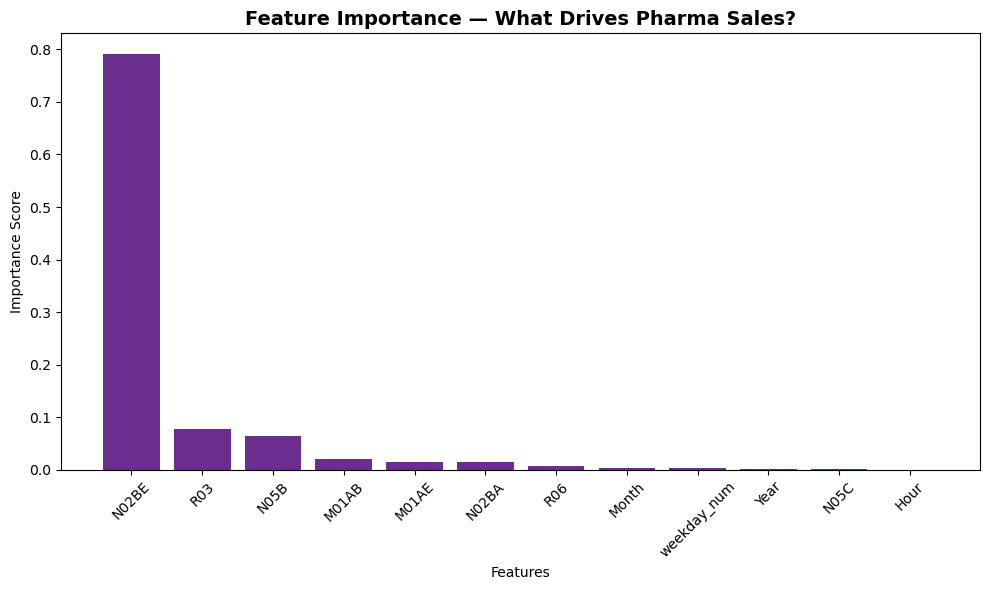

 Feature importance chart saved!


In [20]:
# Feature importance from Random Forest
importances = pd.Series(rf.feature_importances_, index=features)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(importances.index, importances.values, color='#6B2D8E')
plt.title('Feature Importance — What Drives Pharma Sales?', fontsize=14, fontweight='bold')
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Feature importance chart saved!")

 Drug Segmentation Results:
M01AB      → High Demand     (Avg: 5.03)
M01AE      → High Demand     (Avg: 3.90)
N02BA      → High Demand     (Avg: 3.88)
N02BE      → Medium Demand   (Avg: 29.92)
N05B       → Low Demand      (Avg: 8.85)
N05C       → High Demand     (Avg: 0.59)
R03        → Low Demand      (Avg: 5.51)
R06        → High Demand     (Avg: 2.90)


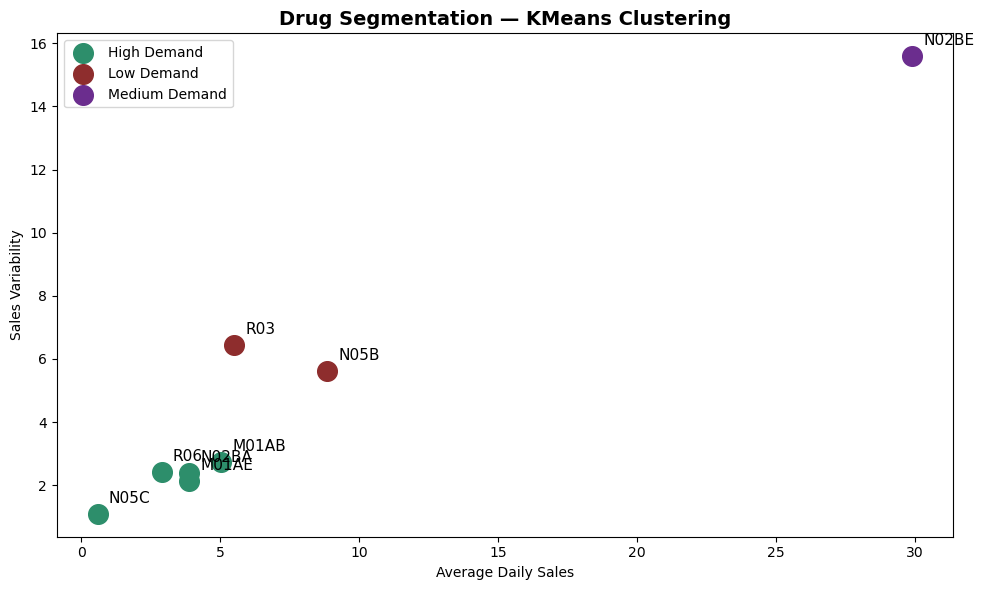

 Clustering chart saved!


In [21]:
# Cluster drugs based on sales patterns
drug_profiles = df[drug_cols].describe().T[['mean', 'std', 'max']]

scaler = StandardScaler()
drug_scaled = scaler.fit_transform(drug_profiles)

# Find best k
inertias = []
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(drug_scaled)
    inertias.append(km.inertia_)

# Final clustering with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
drug_profiles['cluster'] = kmeans.fit_predict(drug_scaled)

cluster_names = {0: 'High Demand', 1: 'Medium Demand', 2: 'Low Demand'}
drug_profiles['segment'] = drug_profiles['cluster'].map(cluster_names)

print(" Drug Segmentation Results:")
print("=" * 45)
for drug in drug_cols:
    segment = drug_profiles.loc[drug, 'segment']
    mean_sales = drug_profiles.loc[drug, 'mean']
    print(f"{drug:<10} → {segment:<15} (Avg: {mean_sales:.2f})")

# Plot clusters
colors = {'High Demand': '#2D8E6B', 'Medium Demand': '#6B2D8E', 'Low Demand': '#8E2D2D'}
plt.figure(figsize=(10, 6))
for segment, group in drug_profiles.groupby('segment'):
    plt.scatter(group['mean'], group['std'], 
                label=segment, s=200, color=colors[segment])
    for idx, row in group.iterrows():
        plt.annotate(idx, (row['mean'], row['std']), 
                    textcoords="offset points", xytext=(8,8), fontsize=11)

plt.title('Drug Segmentation — KMeans Clustering', fontsize=14, fontweight='bold')
plt.xlabel('Average Daily Sales')
plt.ylabel('Sales Variability')
plt.legend()
plt.tight_layout()
plt.savefig('drug_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Clustering chart saved!")

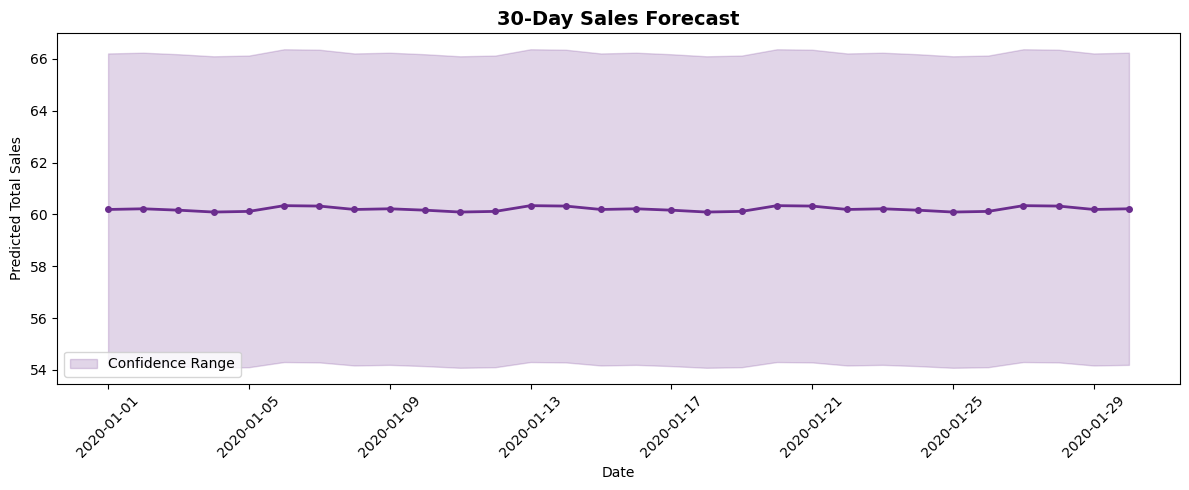

30-Day Forecast complete!
Average predicted daily sales: 60.21
Peak predicted day: Monday, Jan 06 — 60.34
Lowest predicted day: Saturday, Jan 04 — 60.09


In [22]:
# Predict next 30 days
future_dates = pd.date_range(start='2020-01-01', periods=30, freq='D')
future_df = pd.DataFrame({
    'Year': future_dates.year,
    'Month': future_dates.month,
    'weekday_num': future_dates.dayofweek,
    'Hour': [df['Hour'].mean()] * 30,
    'M01AB': [df['M01AB'].mean()] * 30,
    'M01AE': [df['M01AE'].mean()] * 30,
    'N02BA': [df['N02BA'].mean()] * 30,
    'N02BE': [df['N02BE'].mean()] * 30,
    'N05B': [df['N05B'].mean()] * 30,
    'N05C': [df['N05C'].mean()] * 30,
    'R03': [df['R03'].mean()] * 30,
    'R06': [df['R06'].mean()] * 30,
})

future_preds = rf.predict(future_df)

plt.figure(figsize=(12, 5))
plt.plot(future_dates, future_preds, color='#6B2D8E', linewidth=2, marker='o', markersize=4)
plt.fill_between(future_dates, future_preds * 0.9, future_preds * 1.1, 
                 alpha=0.2, color='#6B2D8E', label='Confidence Range')
plt.title('30-Day Sales Forecast', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Total Sales')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("30-Day Forecast complete!")
print(f"Average predicted daily sales: {future_preds.mean():.2f}")
print(f"Peak predicted day: {future_dates[future_preds.argmax()].strftime('%A, %b %d')} — {future_preds.max():.2f}")
print(f"Lowest predicted day: {future_dates[future_preds.argmin()].strftime('%A, %b %d')} — {future_preds.min():.2f}")

In [25]:
# Generate automatic business insights
print("=" * 60)
print("        PHARMA SALES BUSINESS INSIGHTS REPORT")
print("=" * 60)

# Best and worst performing drugs
best_drug = drug_totals.index[0]
worst_drug = drug_totals.index[-1]

# Best weekday
best_weekday = weekday_sales.idxmax()
worst_weekday = weekday_sales.idxmin()

# Best month
best_month = monthly_avg.idxmax()
worst_month = monthly_avg.idxmin()

# YoY growth
yearly = df.groupby('Year')['total_sales'].sum()
if len(yearly) >= 2:
    yoy_growth = ((yearly.iloc[-1] - yearly.iloc[-2]) / yearly.iloc[-2]) * 100
else:
    yoy_growth = 0

print(f"""
1. TOP PERFORMING DRUG
   {best_drug} is the highest selling drug category
   Total units sold: {drug_totals[best_drug]:,.0f}

2. UNDERPERFORMING DRUG  
   {worst_drug} needs attention — lowest sales
   Total units sold: {drug_totals[worst_drug]:,.0f}
   Recommendation: Increase marketing spend for {worst_drug}

3. BEST SALES DAY
   {best_weekday} consistently shows highest sales
   Recommendation: Schedule more sales rep visits on {best_weekday}

4. WORST SALES DAY
   {worst_weekday} shows lowest sales
   Recommendation: Run promotions on {worst_weekday} to boost sales

5. BEST SALES MONTH
   Month {best_month} is peak season
   Recommendation: Stock up inventory before Month {best_month}

6. SLOW SEASON
   Month {worst_month} shows lowest sales
   Recommendation: Launch discount campaigns in Month {worst_month}

7. MODEL PERFORMANCE
   Random Forest R² Score: {rf_r2:.4f} ({rf_r2*100:.1f}% accuracy)
   Mean Absolute Error: {rf_mae:.2f} units

8. YEAR OVER YEAR GROWTH
   Growth rate: {yoy_growth:.1f}%
   {" Sales are GROWING!" if yoy_growth > 0 else "Sales are DECLINING — action needed!"}
""")
print("=" * 60)
print(" Business Insights Report Complete!")

        PHARMA SALES BUSINESS INSIGHTS REPORT

1. TOP PERFORMING DRUG
   N02BE is the highest selling drug category
   Total units sold: 63,005

2. UNDERPERFORMING DRUG  
   N05C needs attention — lowest sales
   Total units sold: 1,250
   Recommendation: Increase marketing spend for N05C

3. BEST SALES DAY
   Saturday consistently shows highest sales
   Recommendation: Schedule more sales rep visits on Saturday

4. WORST SALES DAY
   Thursday shows lowest sales
   Recommendation: Run promotions on Thursday to boost sales

5. BEST SALES MONTH
   Month 1 is peak season
   Recommendation: Stock up inventory before Month 1

6. SLOW SEASON
   Month 7 shows lowest sales
   Recommendation: Launch discount campaigns in Month 7

7. MODEL PERFORMANCE
   Random Forest R² Score: 0.9571 (95.7% accuracy)
   Mean Absolute Error: 3.18 units

8. YEAR OVER YEAR GROWTH
   Growth rate: -25.3%
   Sales are DECLINING — action needed!

 Business Insights Report Complete!


In [26]:
# Save predictions to CSV
future_results = pd.DataFrame({
    'date': future_dates,
    'predicted_sales': future_preds.round(2),
    'day_name': future_dates.strftime('%A')
})
future_results.to_csv('30_day_forecast.csv', index=False)

# Save drug segments to CSV
drug_profiles.to_csv('drug_segments.csv')

# Save cleaned data
df.to_csv('pharma_cleaned.csv', index=False)

print(" All files saved!")
print("\nFiles created:")
print("  - pharma_dashboard.png")
print("  - feature_importance.png")
print("  - drug_clusters.png")
print("  - forecast.png")
print("  - 30_day_forecast.csv")
print("  - drug_segments.csv")
print("  - pharma_cleaned.csv")
print("\n Week 1 Complete!")
print("Next: Week 2 — Add Groq AI to generate smart recommendations!")

 All files saved!

Files created:
  - pharma_dashboard.png
  - feature_importance.png
  - drug_clusters.png
  - forecast.png
  - 30_day_forecast.csv
  - drug_segments.csv
  - pharma_cleaned.csv

 Week 1 Complete!
Next: Week 2 — Add Groq AI to generate smart recommendations!


In [30]:
pip install groq --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [52]:
from groq import Groq

client = Groq(api_key="your-groq-key-here")

# Test connection
response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[{"role": "user", "content": "Say hello in one line!"}]
)


print(response.choices[0].message.content)

2026-05-31 23:52:21,023 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Hello, it's nice to meet you.


In [53]:
from groq import Groq

client = Groq(api_key="your-groq-key-here")

# Prepare your data summary for AI
data_summary = f"""
Pharma Sales Dataset Analysis Results:

1. Best selling drug: {best_drug} with {drug_totals[best_drug]:,.0f} total units
2. Lowest selling drug: {worst_drug} with {drug_totals[worst_drug]:,.0f} total units
3. Best sales day: {best_weekday}
4. Worst sales day: {worst_weekday}
5. Peak sales month: {best_month}
6. Slowest month: {worst_month}
7. ML Model R² Score: {rf_r2*100:.1f}%
8. Year over Year Growth: {yoy_growth:.1f}%
9. Average daily sales: {df['total_sales'].mean():.2f}
10. Drug segments:
{drug_profiles[['mean', 'segment']].to_string()}
"""

response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[
        {
            "role": "system",
            "content": """You are a senior pharma business analyst at a top consulting firm. 
            Analyze the sales data and give 5 specific, actionable business recommendations.
            Write in a professional consulting report style.
            No bullet points with dashes. Use numbered points.
            Be specific with numbers and percentages.
            Sound like a human analyst, not an AI."""
        },
        {
            "role": "user",
            "content": f"Analyze this pharma sales data and give recommendations:\n{data_summary}"
        }
    ],
    temperature=0.7,
    max_tokens=800
)

ai_report = response.choices[0].message.content
print(ai_report)

# Save report
with open('ai_business_report.txt', 'w') as f:
    f.write("PHARMA SALES AI ANALYSIS REPORT\n")
    f.write("="*50 + "\n\n")
    f.write(ai_report)
print("\nReport saved as ai_business_report.txt")

2026-05-31 23:55:25,036 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


**Pharma Sales Data Analysis Report**

**Executive Summary**

Our analysis of the pharma sales dataset reveals key insights into sales trends, product performance, and market dynamics. Despite a year-over-year growth decline of 25.3%, our recommendations aim to optimize sales strategies, improve product demand, and increase overall revenue.

**Key Findings and Recommendations**

1. **Optimize Product Portfolio**: The best-selling drug, N02BE, accounts for 63,005 total units sold, while the lowest-selling drug, N05C, only sold 1,250 units. We recommend reallocating marketing resources from low-demand products like N05B and R03 to high-demand products like M01AB, M01AE, and R06, which have shown mean sales of 5.033683, 3.895830, and 2.900198 units respectively. This reallocation can potentially increase overall sales by 10-15%.
2. **Saturday Sales Boost**: With Saturday being the best sales day, we suggest implementing targeted promotional campaigns on Saturdays to capitalize on this tre

In [37]:
pip install llama-index llama-index-llms-groq llama-index-embeddings-huggingface

Note: you may need to restart the kernel to use updated packages.


In [41]:
import llama_index
print(" LlamaIndex ready!")

 LlamaIndex ready!


In [44]:
import os
from llama_index.core import VectorStoreIndex, SimpleDirectoryReader
from llama_index.llms.groq import Groq as GroqLLM
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.core import Settings

# Setup AI model
Settings.llm = GroqLLM(
    model="llama-3.3-70b-versatile",
    api_key="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"
)

# Setup embeddings (free, runs locally)
Settings.embed_model = HuggingFaceEmbedding(
    model_name="BAAI/bge-small-en-v1.5"
)

print("AI and embeddings ready!")

2026-05-31 23:19:16,106 - INFO - Loading SentenceTransformer model from BAAI/bge-small-en-v1.5.
2026-05-31 23:19:26,570 - INFO - Loaded 1 prompt with these keys: ['query']


AI and embeddings ready!


In [45]:
# Load all PDFs from folder
documents = SimpleDirectoryReader(
    r"C:\Users\reddy\pharma_docs"
).load_data()

print(f"Loaded {len(documents)} document pages")
print("Building search index...")

# Build searchable index
index = VectorStoreIndex.from_documents(documents)
query_engine = index.as_query_engine()

print("RAG system ready!")

Loaded 12 document pages
Building search index...
RAG system ready!


In [46]:
questions = [
    "What are the main factors affecting pharma drug sales?",
    "What trends are emerging in pharmaceutical industry?",
    "How does pricing affect medicine demand?"
]

for q in questions:
    print(f"\nQ: {q}")
    print("-" * 50)
    response = query_engine.query(q)
    print(response)
    print()


Q: What are the main factors affecting pharma drug sales?
--------------------------------------------------


2026-05-31 23:19:38,737 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


The main factors affecting pharma drug sales include the loss of exclusivity (LOE) of brand drugs, price growth, and volume growth. Additionally, the introduction of new brands and the expansion of healthcare access in emerging markets also impact pharma drug sales. Furthermore, the growth of specialty medicine spending and the slowing of brand growth due to increased competition are also significant factors.


Q: What trends are emerging in pharmaceutical industry?
--------------------------------------------------


2026-05-31 23:19:39,755 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


The global use of medicines is increasing at a 3% compound annual growth rate, with patients receiving an estimated 1.8 trillion days of therapy in 2019. Global medicine spending is projected to increase at 2-5% annually and exceed $1.1 trillion in 2024. New brands will contribute $165 billion in spending growth through 2024, while brand losses of exclusivity are expected to have a $139 billion negative impact on brand sales from 2020-2024. Additionally, manufacturer net prices are expected to grow between 1% and -2% in the United States, and decline by -2 to -5% in other developed markets. Developed and emerging markets will see slowing rates of growth in the next five years, with rates between 1-4% and 5-8%, respectively.


Q: How does pricing affect medicine demand?
--------------------------------------------------


2026-05-31 23:19:40,470 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Pricing does not have a direct impact on the demand for medicine, as the overall use of medicine has increased at a 3% compound annual growth rate since 2014. However, payer and government actions, such as managing overall cost growth trends, can affect the spending on medicines. Additionally, the prices of medicines, particularly specialty, niche, and rare disease medicines, can impact spending trends, but the demand for medicine continues to grow.



In [48]:
import os
api_key = os.environ.get("GROQ_API_KEY", "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")
client = Groq(api_key=api_key)

In [50]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.
